In [39]:
import sys
sys.path.insert(0, '..')

from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
import seaborn as sns
import time
import re

from kalshi_core import KalshiClient, pnl_summary, portfolio_kelly, kalshi_order_price
from src.data import (
    load_and_prepare, get_username_mappings,
    load_standings, load_model_predictions,
)
from src.kalshi_tt import get_tt_asks
from src.simulation import (
    build_player_pool, build_player_pool_score,
    run_simulation, run_simulation_score, build_results,
)
from src.portfolio import (
    build_portfolio, run_portfolio_mc, run_portfolio_mc_score,
    run_payoff_matrix, compute_hedge_correlations, show_best_hedges,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_colwidth', 300)

USERNAME_TO_PLAYER, PLAYER_TO_USERNAME = get_username_mappings()
df_standings = load_standings()

_results_raw = load_model_predictions().set_index('username')
for _n in [1, 3, 5, 8, 10]:
    _results_raw[f'P_top{_n}'] = _results_raw['p_participate'] * _results_raw[f'P_top{_n}_given_play']
    _results_raw[f'ip_adv_top{_n}'] = _results_raw[f'P_top{_n}_given_play'] / _results_raw[f'P_top{_n}']
results = _results_raw

In [40]:
client = KalshiClient()
all_asks = get_tt_asks(client)
all_players = list({row["Player Name"] for row in all_asks})

KeyboardInterrupt: 

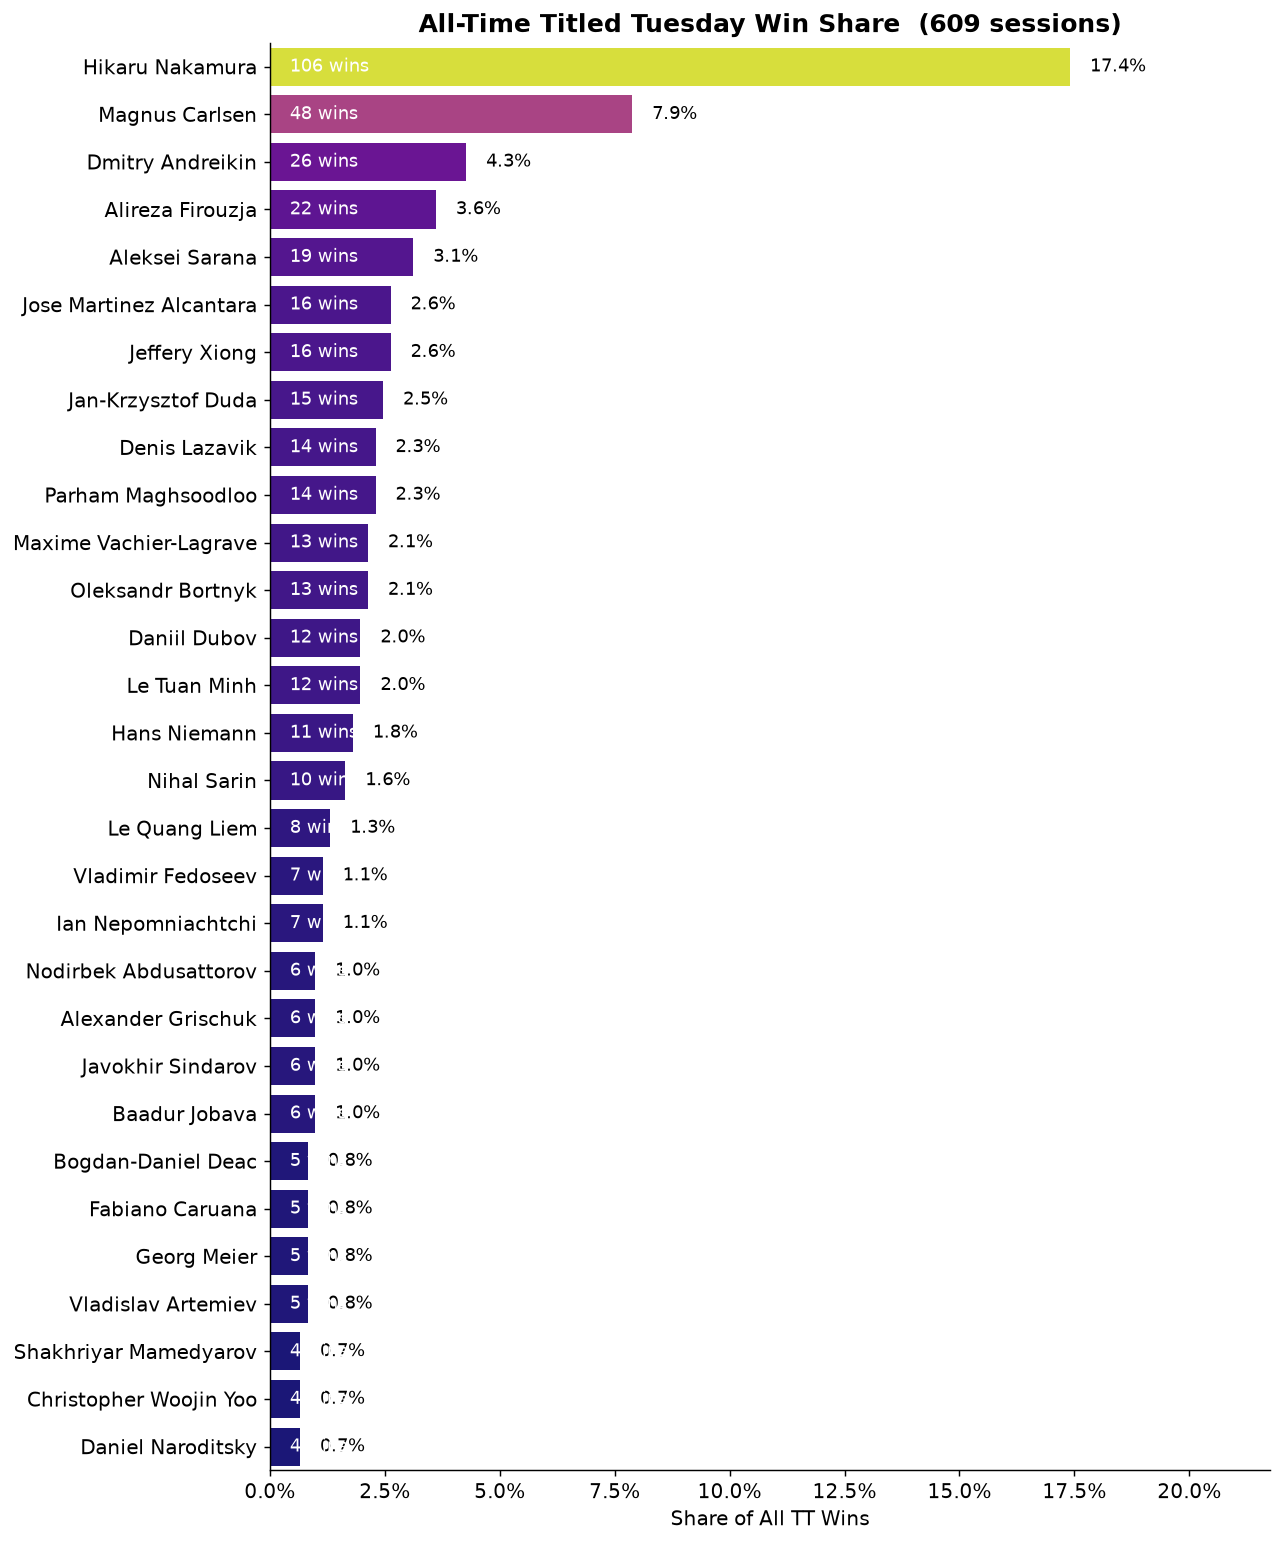

In [41]:
# ── Historical Titled Tuesday win share ──────────────────────────────────────
# "Overall win %" = share of all TT sessions a player has won
# (wins / total number of TT sessions ever held — includes both early and late
# sessions when the twice-weekly schedule was running in 2022-2025).

from src.data import load_tournaments

tournaments = load_tournaments()
n_sessions = len(tournaments)

df_hist = (
    tournaments
    .groupby('winner')
    .size()
    .rename('wins')
    .reset_index()
    .rename(columns={'winner': 'username'})
)
df_hist['win_share'] = df_hist['wins'] / n_sessions
df_hist['name'] = df_hist['username'].apply(lambda u: USERNAME_TO_PLAYER.get(u, u))

df_plot = df_hist.nlargest(30, 'win_share').reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 12))

cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=df_plot['wins'].min(), vmax=df_plot['wins'].max())
colors = cmap(norm(df_plot['wins']))

sns.barplot(data=df_plot, x='win_share', y='name', ax=ax, palette=colors)

ax.set_title(
    f'All-Time Titled Tuesday Win Share  ({n_sessions} sessions)',
    fontweight='bold', fontsize=14,
)

max_width = df_plot['win_share'].max() * 1.25
ax.set_xlim(0, max_width)
ax.set_xlabel('Share of All TT Wins')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

for i, p in enumerate(ax.patches):
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2

    wins_val = int(df_plot.iloc[i]['wins'])
    share_val = df_plot.iloc[i]['win_share']

    ax.text(width + max_width * 0.02, y, f'{share_val*100:.1f}%',
            va='center', ha='left', fontsize=10, color='black')
    ax.text(max_width * 0.02, y, f'{wins_val} wins',
            va='center', ha='left', fontsize=10, color='white')

plt.tight_layout()
plt.show()

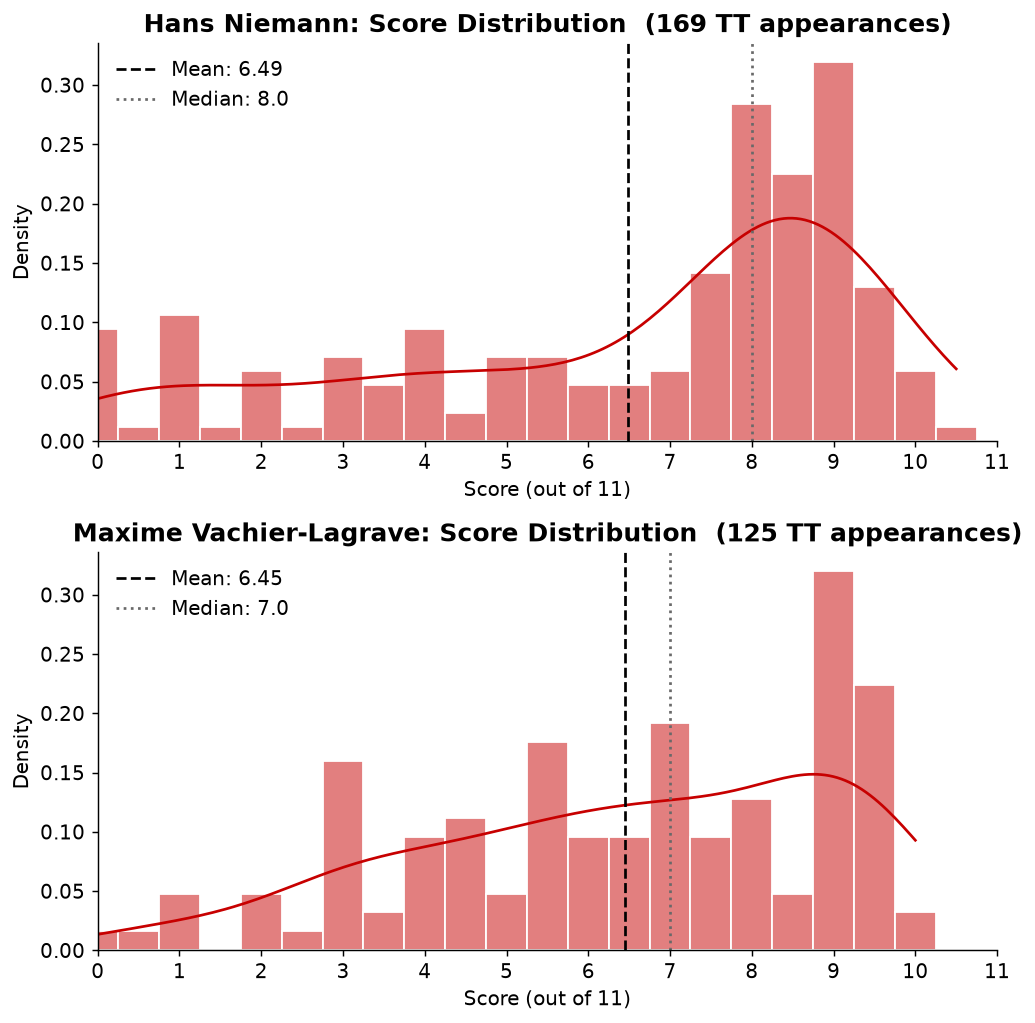

In [94]:
player_names = ['Hans Niemann','Maxime Vachier-Lagrave']

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

for i, player_name in enumerate(player_names):
    _names = df_standings['username'].map(USERNAME_TO_PLAYER)
    scores = df_standings.loc[_names == player_name, 'score'].dropna()
    # Half-point-centered bins (TT scores are in 0.5-point increments, max 11)
    bin_edges = np.arange(-0.25, 11.5, 0.5)
    sns.histplot(x=scores, bins=bin_edges, kde=True, stat='density',
                color="#C70000", edgecolor='white', ax=axes[i])

    mean_score = scores.mean()
    median_score = scores.median()
    axes[i].axvline(mean_score, color='black', linestyle='--', linewidth=1.5,
            label=f'Mean: {mean_score:.2f}')
    axes[i].axvline(median_score, color='dimgray', linestyle=':', linewidth=1.5,
            label=f'Median: {median_score:.1f}')

    axes[i].set_title(
        f'{player_name}: Score Distribution  ({len(scores)} TT appearances)',
        fontweight='bold', fontsize=14,
    )
    axes[i].set_xlabel('Score (out of 11)')
    axes[i].set_ylabel('Density')
    axes[i].set_xlim(0, 11)
    axes[i].set_xticks(np.arange(0, 11.5, 1))
    axes[i].legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

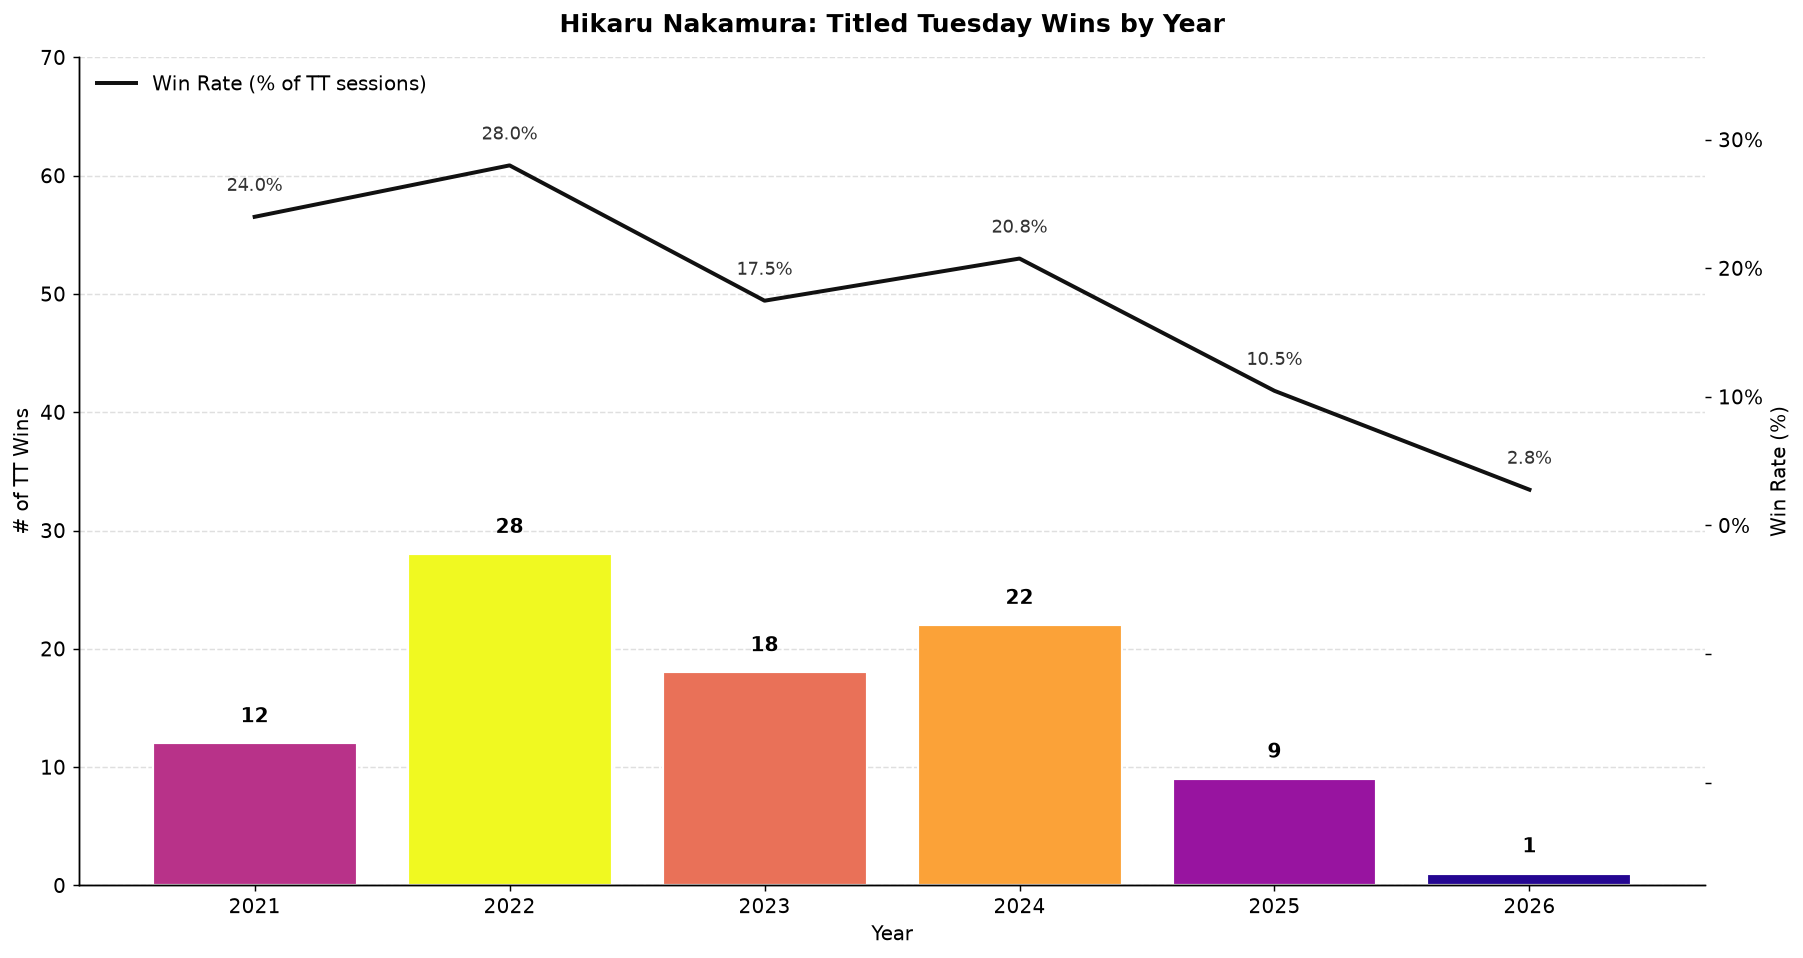

In [43]:
# ── Hikaru Nakamura: Titled Tuesday wins by year ─────────────────────────────
player_name = 'Hikaru Nakamura'

_players = tournaments['winner'].map(USERNAME_TO_PLAYER)
_years = tournaments.loc[_players == player_name, 'date'].dt.year

year_max = int(tournaments['date'].dt.year.max())
year_min = year_max - 5   # last 6 years
years = np.arange(year_min, year_max + 1)

wins_series = _years.value_counts().reindex(years, fill_value=0)
sessions_series = tournaments['date'].dt.year.value_counts().reindex(years, fill_value=0)

wins_by_year = pd.DataFrame({
    'year': years,
    'wins': wins_series.values,
    'sessions': sessions_series.values,
})
wins_by_year['win_rate'] = np.where(
    wins_by_year['sessions'] > 0,
    wins_by_year['wins'] / wins_by_year['sessions'],
    np.nan,
)

bar_max  = max(wins_by_year['wins'].max(), 1)
rate_max = max(wins_by_year['win_rate'].max(), 0.01)

fig, ax = plt.subplots(1, 1, figsize=(14, 7.5))

cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=0, vmax=bar_max)
colors = cmap(norm(wins_by_year['wins']))

bars = ax.bar(wins_by_year['year'], wins_by_year['wins'],
              color=colors, edgecolor='white', linewidth=1.2, zorder=2)

ax.set_title(f'{player_name}: Titled Tuesday Wins by Year',
             fontweight='bold', fontsize=14, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('# of TT Wins')
ax.set_xticks(years)
# Bars occupy bottom ~40% of the chart
ax.set_ylim(0, bar_max * 2.5)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for bar, w in zip(bars, wins_by_year['wins']):
    if w > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bar_max * 0.05,
                f'{int(w)}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

# Overlay: yearly win rate (Hikaru's wins / total TT sessions that year)
# ax2 limits are offset so the line renders in the top half — no overlap with bars
ax2 = ax.twinx()
ax2.plot(wins_by_year['year'], wins_by_year['win_rate'],
         color='#111111', linewidth=2.2, zorder=3,
         label='Win Rate (% of TT sessions)')
ax2.set_ylabel('Win Rate (%)')
ax2.set_ylim(-rate_max, rate_max * 1.3)
# Hide negative ticks; only show positive win-rate values
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'{v*100:.0f}%' if v >= 0 else '')
)
ax2.spines['top'].set_visible(False)

for _, row in wins_by_year.iterrows():
    if pd.notna(row['win_rate']) and row['win_rate'] > 0:
        ax2.text(row['year'], row['win_rate'] + rate_max * 0.06,
                 f'{row["win_rate"]*100:.1f}%',
                 ha='center', va='bottom', fontsize=10, color='#333333')

ax2.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

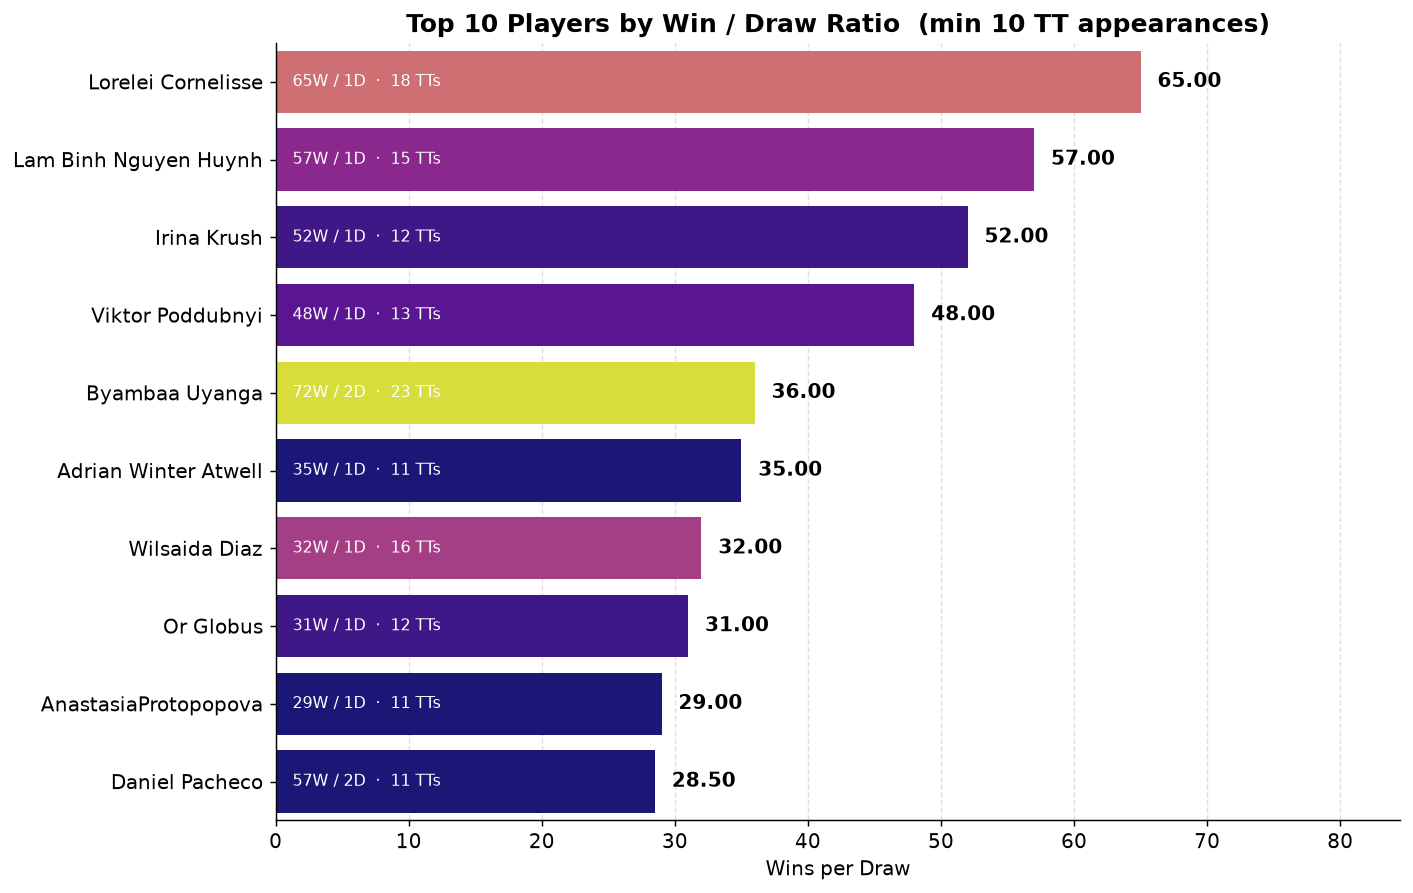

In [44]:
# ── Top 10 players by career Win / Draw ratio (min 10 TT appearances) ────────
MIN_APPEARANCES = 10

df_wd = (
    df_standings
    .groupby('username')
    .agg(wins=('wins', 'sum'),
         draws=('draws', 'sum'),
         appearances=('wins', 'size'))
    .reset_index()
)
df_wd = df_wd[(df_wd['appearances'] > MIN_APPEARANCES) & (df_wd['draws'] > 0)].copy()
df_wd['wd_ratio'] = df_wd['wins'] / df_wd['draws']
df_wd['name'] = df_wd['username'].apply(lambda u: USERNAME_TO_PLAYER.get(u, u))

df_plot = df_wd.nlargest(10, 'wd_ratio').reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize=(11, 7))

cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=df_plot['appearances'].min(),
                         vmax=df_plot['appearances'].max())
colors = cmap(norm(df_plot['appearances']))

sns.barplot(data=df_plot, x='wd_ratio', y='name', ax=ax, palette=colors)

ax.set_title(
    f'Top 10 Players by Win / Draw Ratio  '
    f'(min {MIN_APPEARANCES} TT appearances)',
    fontweight='bold', fontsize=14,
)

max_width = df_plot['wd_ratio'].max() * 1.30
ax.set_xlim(0, max_width)
ax.set_xlabel('Wins per Draw')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2

    row = df_plot.iloc[i]
    ax.text(width + max_width * 0.015, y,
            f'{row["wd_ratio"]:.2f}',
            va='center', ha='left', fontsize=11, fontweight='bold', color='black')
    ax.text(max_width * 0.015, y,
            f'{int(row["wins"])}W / {int(row["draws"])}D  ·  {int(row["appearances"])} TTs',
            va='center', ha='left', fontsize=9, color='white')

plt.tight_layout()
plt.show()

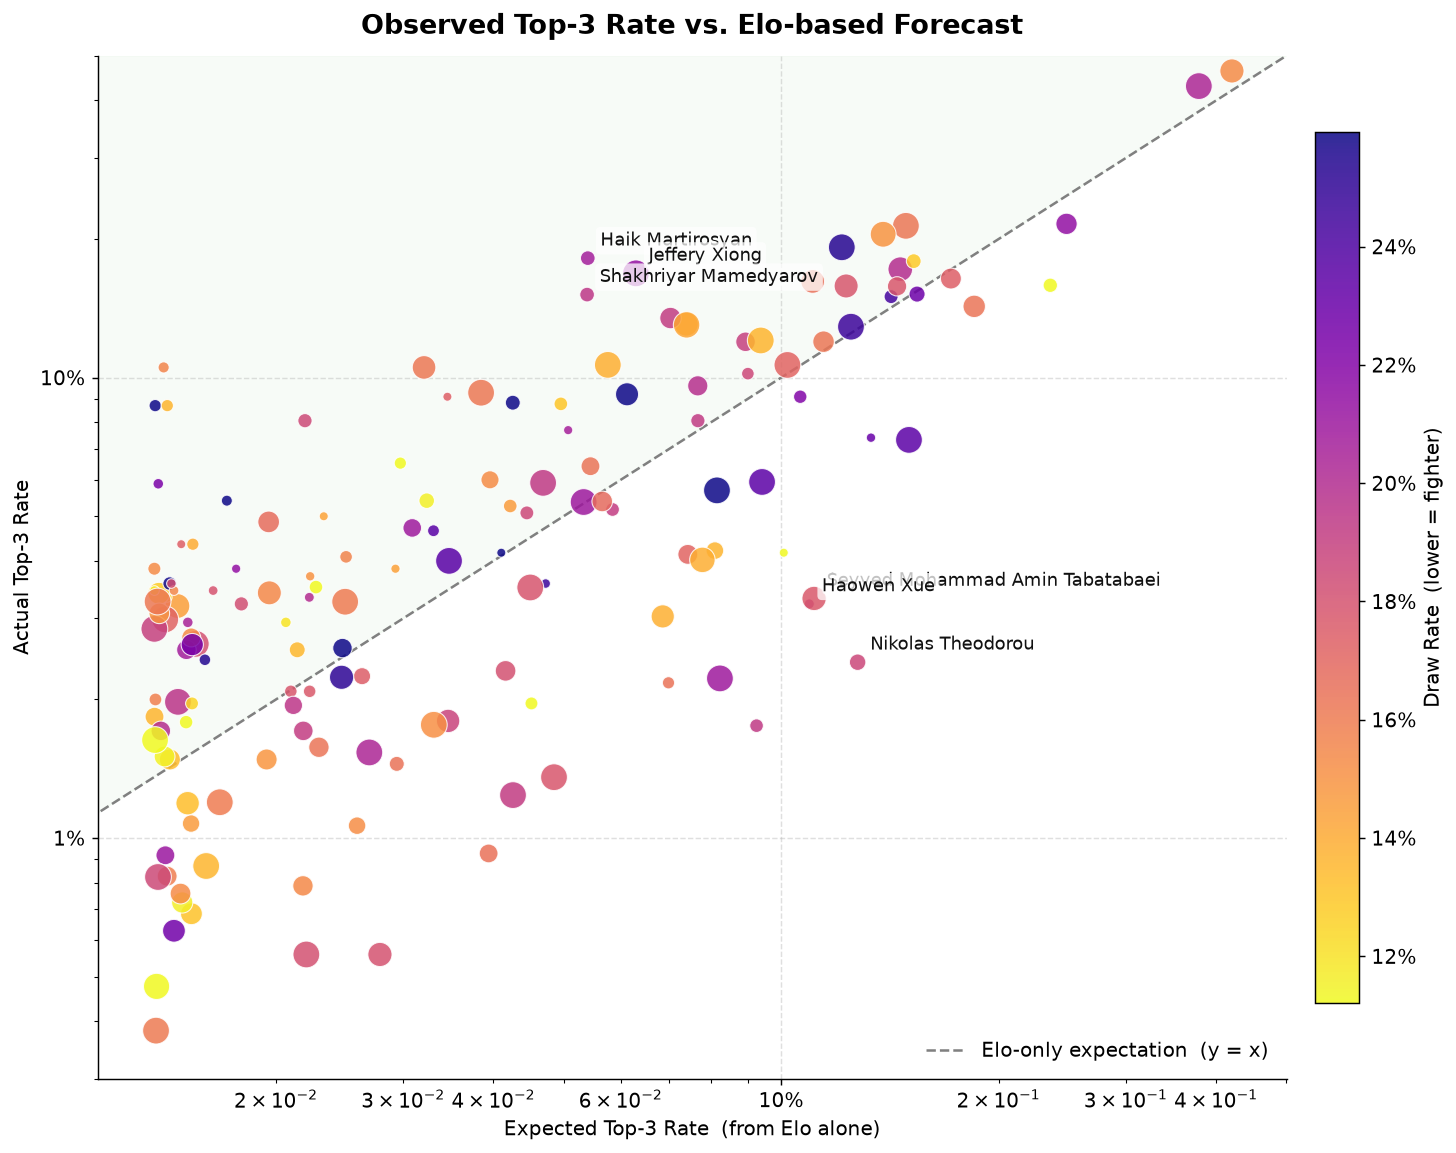

In [60]:
# ── Fighters overperform: Actual vs Elo-Expected Top-N rate ──────────────────
# Story: at a given Elo, players with LOW draw rates finish in the top-N
# more often than their drawish peers. Points above the y=x line are
# overperformers relative to what their rating alone predicts.

N = 3
MIN_APPEARANCES = 20
MIN_RATING = 2900
ROUNDS_PER_TT = 11
df_standings['rating']=pd.to_numeric(df_standings['rating'], errors='coerce')
player_stats = (
    df_standings
    .assign(is_topN=(df_standings['rank'] <= N).astype(int))
    .groupby('username')
    .agg(
        appearances=('rank', 'size'),
        avg_rating=('rating', 'mean'),
        wins=('wins', 'sum'),
        draws=('draws', 'sum'),
        byes=('byes', 'sum'),
        topN_count=('is_topN', 'sum'),
    )
    .reset_index()
)
player_stats = player_stats[(player_stats['appearances'] >= MIN_APPEARANCES) & (player_stats['avg_rating'] >= MIN_RATING)].copy()

# Total decisive games played (rounds minus byes)
player_stats['total_games'] = player_stats['appearances'] * ROUNDS_PER_TT - player_stats['byes']
player_stats['draw_rate']   = player_stats['draws'] / player_stats['wins']
player_stats['topN_rate']   = player_stats['topN_count'] / player_stats['appearances']
player_stats['name']        = player_stats['username'].apply(lambda u: USERNAME_TO_PLAYER.get(u, u))

ps = player_stats.dropna(subset=['avg_rating', 'draw_rate', 'topN_rate']).copy()

# Elo-only expectation: fit topN_rate as a smooth function of avg_rating
coeffs = np.polyfit(ps['avg_rating'], ps['topN_rate'], deg=2)
ps['expected_topN'] = np.polyval(coeffs, ps['avg_rating']).clip(0, 1)
ps['residual']      = ps['topN_rate'] - ps['expected_topN']

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

# plasma_r so LOW draw rate (fighter) shows BRIGHT
cmap = plt.get_cmap('plasma_r')
norm = mcolors.Normalize(vmin=ps['draw_rate'].quantile(0.05),
                         vmax=ps['draw_rate'].quantile(0.95))
sizes = np.clip(ps['appearances'], 25, 220)

sc = ax.scatter(ps['expected_topN'], ps['topN_rate'],
                c=ps['draw_rate'], cmap=cmap, norm=norm,
                s=sizes, edgecolor='white', linewidth=0.6, alpha=0.85, zorder=2)

# y = x reference line (Elo-only expectation)
lim_max = max(ps['expected_topN'].max(), ps['topN_rate'].max()) * 1.08
ax.plot([0, lim_max], [0, lim_max],
        color='gray', linestyle='--', linewidth=1.4, zorder=1,
        label='Elo-only expectation  (y = x)')

# Shaded overperformance region
ax.fill_between([0, lim_max], [0, lim_max], [lim_max, lim_max],
                color='#7ec97e', alpha=0.06, zorder=0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)
ax.set_xlabel(f'Expected Top-{N} Rate  (from Elo alone)')
ax.set_ylabel(f'Actual Top-{N} Rate')
ax.set_title(
    f'Observed Top-{N} Rate vs. Elo-based Forecast',
    fontweight='bold', fontsize=15, pad=12,
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Annotate the 3 biggest overperformers and 3 biggest underperformers
labeled = pd.concat([ps.nlargest(3, 'residual'), ps.nsmallest(3, 'residual')])
for _, r in labeled.iterrows():
    ax.annotate(r['name'],
                xy=(r['expected_topN'], r['topN_rate']),
                xytext=(7, 7), textcoords='offset points',
                fontsize=10, color='#111',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='none', alpha=0.75))

# Colorbar for draw rate
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Draw Rate  (lower = fighter)')
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

ax.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

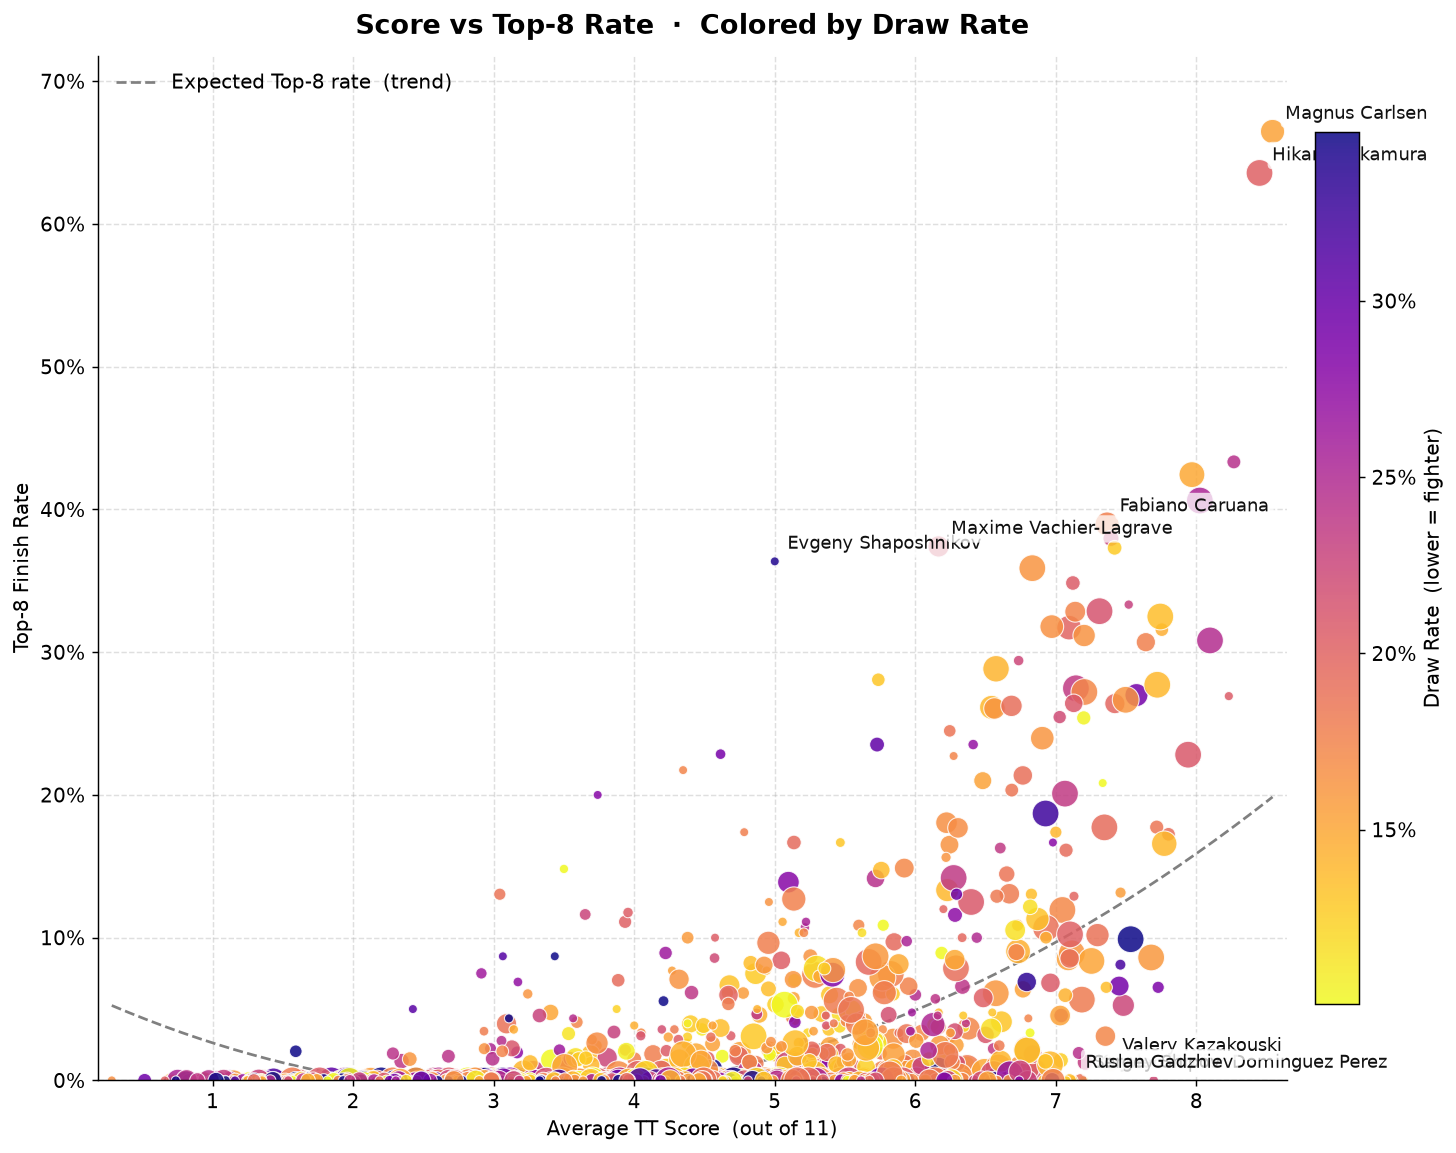

In [92]:
# ── Expected Score vs Top-N rate, colored by draw rate ───────────────────────
# X: player's average score across their TT appearances (their "expected score
#    out of 11" — a data-driven skill proxy that doesn't rely on Elo).
# Y: % of appearances finishing in the top N.
# Color: draw rate (fighter = bright, drawish = dark).

N = 8
MIN_APPEARANCES = 20
ROUNDS_PER_TT = 11

player_stats = (
    df_standings
    .assign(is_topN=(df_standings['rank'] <= N).astype(int))
    .groupby('username')
    .agg(
        appearances=('rank', 'size'),
        mean_score=('score', 'mean'),
        wins=('wins', 'sum'),
        draws=('draws', 'sum'),
        byes=('byes', 'sum'),
        topN_count=('is_topN', 'sum'),
    )
    .reset_index()
)
player_stats = player_stats[player_stats['appearances'] >= MIN_APPEARANCES].copy()

player_stats['total_games'] = player_stats['appearances'] * ROUNDS_PER_TT - player_stats['byes']
player_stats['draw_rate']   = player_stats['draws'] / player_stats['wins']
player_stats['topN_rate']   = player_stats['topN_count'] / player_stats['appearances']
player_stats['name']        = player_stats['username'].apply(lambda u: USERNAME_TO_PLAYER.get(u, u))

ps = player_stats.dropna(subset=['mean_score', 'draw_rate', 'topN_rate']).copy()

# Trend line: expected top-N rate given mean score (poly deg 2, clipped)
x_grid = np.linspace(ps['mean_score'].min(), ps['mean_score'].max(), 200)
coeffs = np.polyfit(ps['mean_score'], ps['topN_rate'], deg=2)
y_grid = np.clip(np.polyval(coeffs, x_grid), 0, 1)
ps['expected_topN'] = np.polyval(coeffs, ps['mean_score']).clip(0, 1)
ps['residual']      = ps['topN_rate'] - ps['expected_topN']

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

cmap = plt.get_cmap('plasma_r')
norm = mcolors.Normalize(vmin=ps['draw_rate'].quantile(0.05),
                         vmax=ps['draw_rate'].quantile(0.95))
sizes = np.clip(ps['appearances'], 25, 220)

sc = ax.scatter(ps['mean_score'], ps['topN_rate'],
                c=ps['draw_rate'], cmap=cmap, norm=norm,
                s=sizes, edgecolor='white', linewidth=0.6, alpha=0.85, zorder=2)

# Trend curve: what the average player scoring X out of 11 finishes at
ax.plot(x_grid, y_grid, color='gray', linestyle='--', linewidth=1.5, zorder=1,
        label=f'Expected Top-{N} rate  (trend)')

# ax.set_yscale('log')
ax.set_xlim(x_grid.min() - 0.1, x_grid.max() + 0.1)
ax.set_ylim(0, max(ps['topN_rate'].max() * 1.08, 0.05))
ax.set_xlabel('Average TT Score  (out of 11)')
ax.set_ylabel(f'Top-{N} Finish Rate')
ax.set_title(
    f'Score vs Top-{N} Rate  ·  Colored by Draw Rate',
    fontweight='bold', fontsize=15, pad=12,
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Annotate biggest over- and under-performers versus the trend
labeled = pd.concat([ps.nlargest(5, 'residual'), ps.nsmallest(5, 'residual')])
for _, r in labeled.iterrows():
    ax.annotate(r['name'],
                xy=(r['mean_score'], r['topN_rate']),
                xytext=(7, 7), textcoords='offset points',
                fontsize=10, color='#111',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='none', alpha=0.75))

cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Draw Rate  (lower = fighter)')
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

ax.legend(loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

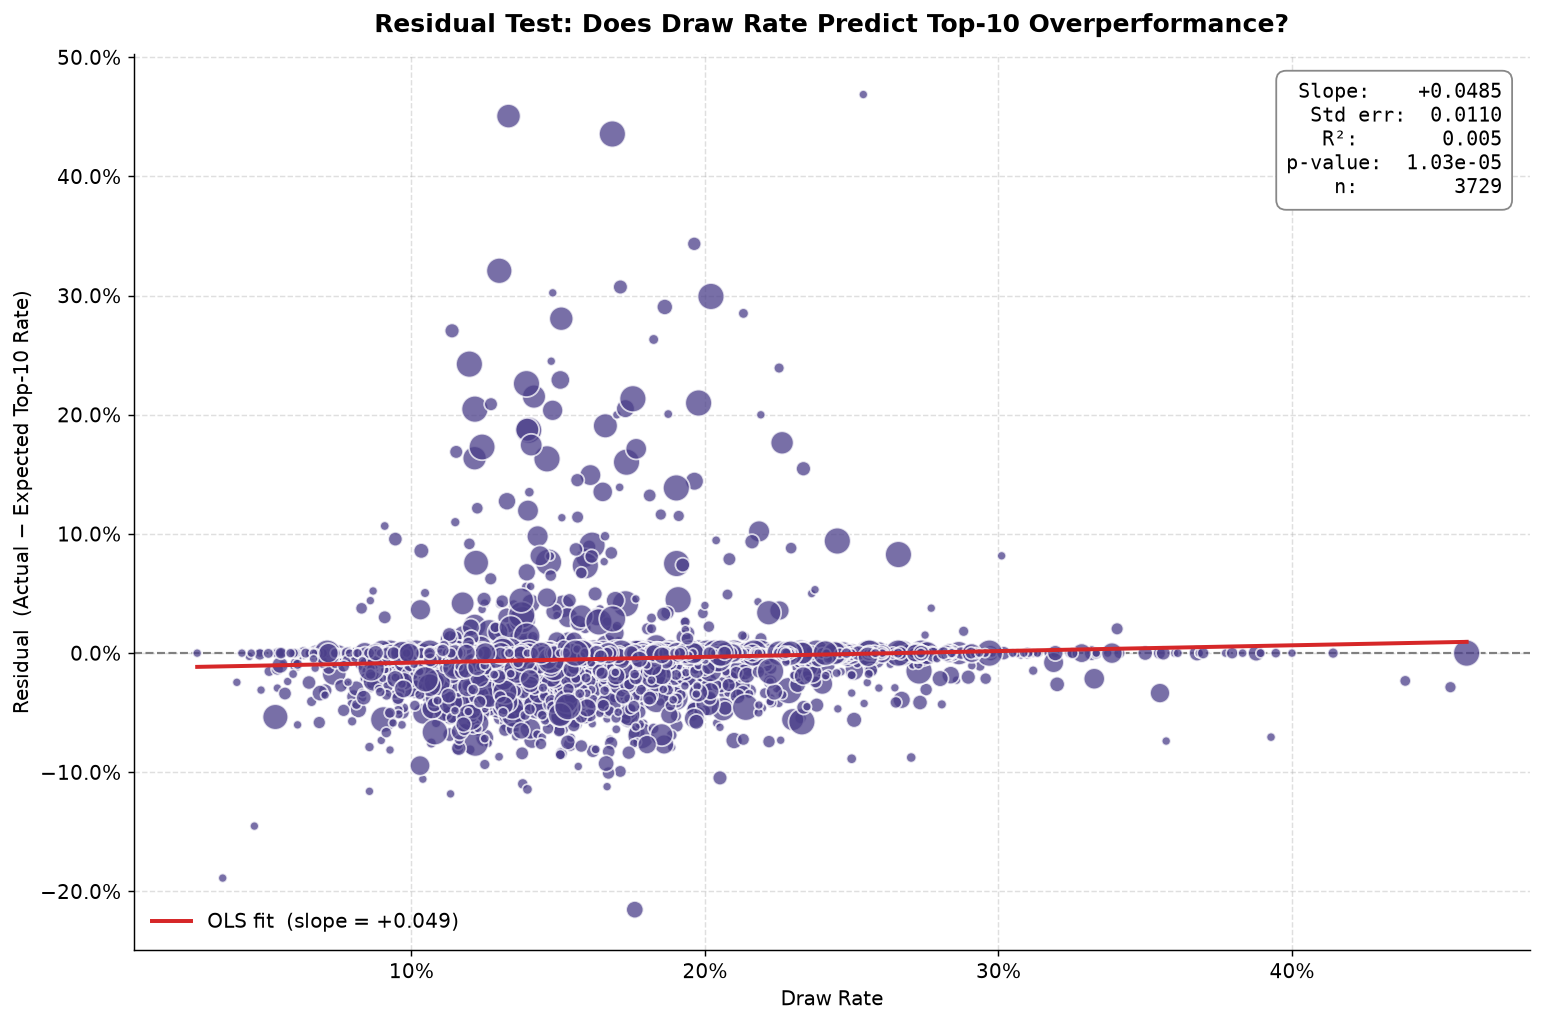

SIGNIFICANT POSITIVE slope (p=1.03e-05). Drawish players actually overperform — the fighter hypothesis is inverted here.


In [91]:
# ── Residual test: does draw rate actually predict overperformance? ──────────
# Regress residual (actual − expected top-N rate) on draw rate.
# If "fighters overperform" is real, the slope is NEGATIVE and significant.
# If the effect is spurious, slope ≈ 0 or p-value is high.

from scipy import stats

N_TEST = 10
MIN_APP = 20
ROUNDS = 11

ps_test = (
    df_standings
    .assign(is_topN=(df_standings['rank'] <= N_TEST).astype(int))
    .groupby('username')
    .agg(
        appearances=('rank', 'size'),
        avg_rating=('rating', 'mean'),
        mean_score=('score', 'mean'),
        draws=('draws', 'sum'),
        wins=('wins', 'sum'),
        byes=('byes', 'sum'),
        topN_count=('is_topN', 'sum'),
    )
    .reset_index()
)
ps_test = ps_test[ps_test['appearances'] >= MIN_APP].copy()
ps_test['total_games'] = ps_test['wins'] + ps_test['draws']
# ps_test['total_games'] = ps_test['appearances'] * ROUNDS - ps_test['byes']
ps_test['draw_rate']   = ps_test['draws'] / ps_test['total_games']
ps_test['topN_rate']   = ps_test['topN_count'] / ps_test['appearances']
ps_test = ps_test.dropna(subset=['avg_rating', 'draw_rate', 'topN_rate'])

# Elo-free expectation: same poly-deg-2 fit on mean score as the scatter above
coeffs = np.polyfit(ps_test['avg_rating'], ps_test['topN_rate'], deg=2)
ps_test['expected'] = np.polyval(coeffs, ps_test['avg_rating']).clip(0, 1)
ps_test['residual'] = ps_test['topN_rate'] - ps_test['expected']

# Linear regression: residual ~ draw_rate
lr = stats.linregress(ps_test['draw_rate'], ps_test['residual'])
slope, intercept, r_value, p_value, stderr = lr

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.scatter(ps_test['draw_rate'], ps_test['residual'],
           s=np.clip(ps_test['appearances'], 25, 220),
           c='#4b3f8a', edgecolor='white', alpha=0.75, zorder=2)

x_grid = np.linspace(ps_test['draw_rate'].min(), ps_test['draw_rate'].max(), 200)
ax.plot(x_grid, slope * x_grid + intercept,
        color='#d62728', linewidth=2.2, zorder=3,
        label=f'OLS fit  (slope = {slope:+.3f})')

ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, zorder=1)

stats_str = (
    f'Slope:    {slope:+.4f}\n'
    f'Std err:  {stderr:.4f}\n'
    f'R²:       {r_value**2:.3f}\n'
    f'p-value:  {p_value:.2e}\n'
    f'n:        {len(ps_test)}'
)
ax.text(0.98, 0.97, stats_str,
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#888'))
ax.set_xlabel('Draw Rate')
ax.set_ylabel(f'Residual  (Actual − Expected Top-{N_TEST} Rate)')
ax.set_title(
    f'Residual Test: Does Draw Rate Predict Top-{N_TEST} Overperformance?',
    fontweight='bold', fontsize=14, pad=12,
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.grid(linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc='lower left', frameon=False)

plt.tight_layout()
plt.show()
labeled = pd.concat([ps.nlargest(3, 'residual'), ps.nsmallest(3, 'residual')])
for _, r in labeled.iterrows():
    ax.annotate(r['name'],
                xy=(r['mean_score'], r['topN_rate']),
                xytext=(7, 7), textcoords='offset points',
                fontsize=10, color='#111',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='none', alpha=0.75))
# Plain-English verdict
if p_value < 0.05 and slope < 0:
    verdict = (
        f"SIGNIFICANT NEGATIVE slope (p={p_value:.2e}). "
        f"At the same average score, lower-draw-rate players finish top-{N_TEST} "
        f"more often — 'fighters overperform' holds up."
    )
elif p_value < 0.05 and slope > 0:
    verdict = (
        f"SIGNIFICANT POSITIVE slope (p={p_value:.2e}). "
        f"Drawish players actually overperform — the fighter hypothesis is inverted here."
    )
else:
    verdict = (
        f"NO significant relationship (p={p_value:.2f}, R²={r_value**2:.3f}). "
        f"Draw rate does not meaningfully predict top-{N_TEST} overperformance "
        f"once average score is controlled for."
    )
print(verdict)